# Music Preference Matching Using Manhattan Distance

## Project Overview

This project explores how Manhattan Distance can be applied in a simple music recommendation and user similarity system.

The notebook demonstrates how user music preferences can be represented as numerical features and compared mathematically to identify similar users. Several important concepts in data science and recommendation systems are explored throughout the project, including:

- Distance Metrics
- Similarity Analysis
- Feature Engineering
- Categorical Encoding
- Scaling and Normalization
- Weighted Manhattan Distance

The project uses a synthetic dataset containing music-related attributes such as:

- Tempo
- Energy
- Acousticness
- Danceability
- Genre
- Mood

The main objective is to understand how mathematical distance can be used to measure similarity between users and how feature preprocessing affects recommendation outcomes.

This notebook is intended as an educational exploration of foundational concepts behind recommendation systems and similarity-based machine learning approaches.

### Synthetic Dataset

In [1]:
import pandas as pd

data = [
["U1",8,6,3,9],
["U2",7,5,4,8],
["U3",3,4,8,2],
["U4",9,8,2,9],
["U5",6,7,5,7],
["U6",2,3,9,1],
["U7",8,9,2,8],
["U8",5,6,6,6],
["U9",4,3,7,3],
["U10",9,8,1,9],
["U11",7,6,4,7],
["U12",3,2,9,2],
["U13",6,7,5,6],
["U14",8,8,3,8],
["U15",2,3,8,2],
["U16",9,9,1,10],
["U17",5,5,6,5],
["U18",4,4,7,4],
["U19",7,8,3,7],
["U20",3,2,9,1],
["U21",8,7,2,9],
["U22",6,5,5,6],
["U23",2,3,9,2],
["U24",9,9,1,9],
["U25",7,6,4,7],
["U26",5,4,6,5],
["U27",4,3,8,3],
["U28",8,9,2,8],
["U29",6,6,5,6],
["U30",3,2,9,1],
["U31",9,8,2,9],
["U32",7,7,3,8],
["U33",5,5,6,5],
["U34",4,4,7,4],
["U35",2,3,9,2],
["U36",8,8,2,9],
["U37",6,7,5,6],
["U38",3,3,8,2],
["U39",9,9,1,10],
["U40",7,6,4,7],
["U41",5,5,6,5],
["U42",4,3,7,3],
["U43",2,2,9,1],
["U44",8,9,2,8],
["U45",6,6,5,6],
["U46",3,2,8,2],
["U47",9,8,1,9],
["U48",7,7,3,8],
["U49",5,4,6,5],
["U50",4,3,7,3],
]

df = pd.DataFrame(data, columns=["User","Tempo","Energy","Acousticness","Danceability"])

df.to_csv("music_users_clean.csv", index=False)

In [2]:
print(df.columns)
print(df.head())

Index(['User', 'Tempo', 'Energy', 'Acousticness', 'Danceability'], dtype='object')
  User  Tempo  Energy  Acousticness  Danceability
0   U1      8       6             3             9
1   U2      7       5             4             8
2   U3      3       4             8             2
3   U4      9       8             2             9
4   U5      6       7             5             7


## Tambah Fitur Baru

- Genre (Pop, Rock, Jazz)
- Mood (Happy, Sad, Chill)

In [3]:
import numpy as np

np.random.seed(42)

genres = ["Pop","Rock","Jazz"]
moods = ["Happy","Sad","Chill"]

df["Genre"] = np.random.choice(genres, len(df))
df["Mood"] = np.random.choice(moods, len(df))

print(df.head())

  User  Tempo  Energy  Acousticness  Danceability Genre   Mood
0   U1      8       6             3             9  Jazz    Sad
1   U2      7       5             4             8   Pop  Happy
2   U3      3       4             8             2  Jazz    Sad
3   U4      9       8             2             9  Jazz  Happy
4   U5      6       7             5             7   Pop    Sad


## Encoding (Important)
Genre & Mood adalah kategori -> Kita ubah ke angka

In [4]:
df_encoded = pd.get_dummies(df, columns=["Genre", "Mood"])

print(df_encoded.head())

  User  Tempo  Energy  Acousticness  Danceability  Genre_Jazz  Genre_Pop  \
0   U1      8       6             3             9        True      False   
1   U2      7       5             4             8       False       True   
2   U3      3       4             8             2        True      False   
3   U4      9       8             2             9        True      False   
4   U5      6       7             5             7       False       True   

   Genre_Rock  Mood_Chill  Mood_Happy  Mood_Sad  
0       False       False       False      True  
1       False       False        True     False  
2       False       False       False      True  
3       False       False        True     False  
4       False       False       False      True  


### MANHATTAN DISTANCE FUNCTION

In [5]:
def manhattan_distance(user1, user2):
    return np.sum(np.abs(user1 - user2))

### Find similar users

In [6]:
def find_similar_users(df, target_user_id, top_n=5):
    #ambil data numerik saja
    df_numeric = df.drop(columns=["User"])

    # ambil target user
    target_vector = df_numeric[df["User"] == target_user_id].values[0]

    distances = []

    for i, row in df_numeric.iterrows():
        user_id = df.iloc[i]["User"]

        if user_id == target_user_id:
            continue

        dist = manhattan_distance(target_vector, row.values)
        distances.append((user_id, dist))

    # sort by smallest distance
    distances.sort(key=lambda x: x[1])

    return distances[:top_n]

In [7]:
#df_encoded = df_encoded.reset_index()

## Testing 

In [8]:
similar_users = find_similar_users(df_encoded, "U1", top_n=5)

for user, dist in similar_users:
    print(f"{user} -> Distance: {dist}")

U14 -> Distance: 3
U11 -> Distance: 4
U32 -> Distance: 5
U36 -> Distance: 5
U4 -> Distance: 6


## Apakah arti dari hasil ini?

- U14 = "closest twin" dari U1
- U11 = juga cukup mirip
- U4 mulai agak Beda

## Validasi dengan membandingkan fitur-fiturnya
👉 Lihat:

- Tempo
- Energy
- Acousticness
- Danceability
- Genre
- Mood

In [9]:
df[df["User"].isin(["U14","U11","U32","U36","U4"])]

,User,Tempo,Energy,Acousticness,Danceability,Genre,Mood
3,U4,9,8,2,9,Jazz,Happy
10,U11,7,6,4,7,Jazz,Sad
13,U14,8,8,3,8,Jazz,Sad
31,U32,7,7,3,8,Jazz,Happy
35,U36,8,8,2,9,Rock,Sad


### Coba Membandingkan dua yang paling dekat U1

In [10]:
df[df["User"].isin(["U1","U14"])]

,User,Tempo,Energy,Acousticness,Danceability,Genre,Mood
0,U1,8,6,3,9,Jazz,Sad
13,U14,8,8,3,8,Jazz,Sad


## Kenapa U14 paling dekat?
- Temponya mirip (8)
- Energy (selisnya 2)
- Acousticness mirip(3)
- Danceability (selisnya 1)
- Genre mirip (jazz)
- Mood mirip (sad)

## INSIGHT
    User U1 memiliki kemiripan tertinggi dengan U14 berdasarkan Manhattan Distance (3), Menunjukan preferensi yang sangat dekat dalam fitur Tempo, Energy, Acousticness, Danceabilitiy, Genre, dan Mood. Hal ini menunjukan bahwa sistem mampu mengidentifikasi user dengan selera musik yang sama

# Critical Thinking time !!

- Thingking about "APAKAH HASIL INI BENAR-BENAR ADIL"?
- Apakah semua fitur diperlakukan sama?
- Apakah model ini bias?

### Mari kita bedah fitur ini!

| Feature      | Type        | Range |
| ------------ | ----------- | ----- |
| Tempo        | Numeric     | 1–10  |
| Energy       | Numeric     | 1–10  |
| Acousticness | Numeric     | 1–10  |
| Danceability | Numeric     | 1–10  |
| Genre_Jazz   | Categorical | 0 / 1 |
| Mood_Sad     | Categorical | 0 / 1 |

### Yesss Take a look, Numerical features are dominant !!
## MASALAHANNYA !!!
Manhattan Distance 

- 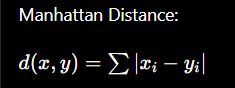

- 👉 Semua selisih dijumlahkan

- Contoh nyata:
Misalnya:

- Tempo beda = 3
- Genre beda = 1 (karena 0 vs 1)

👉 Maka: Tempo lebih “berpengaruh” daripada Genre.

💥 Artinya:

- 👉 Model ini “lebih peduli” ke angka besar
- 👉 Feature kecil (genre, mood) jadi kurang penting

#### ➡️ Ini yang disebut:
#### numerical features dominate the distance

## 🔷 3. Jadi… kenapa ini penting?

Kalau tidak diperbaiki:
👉 Sistem kamu akan bilang:

“Yang penting tempo sama”

Padahal:
👉 Bisa jadi user lebih peduli:

genre
mood


# SOLUSINYA ADALAH SCALING / NORMALIZATION !!!
🔹 Intinya:

👉 Kita ubah semua fitur ke skala yang sama
- Biasanya ke: 0 sampai .

- 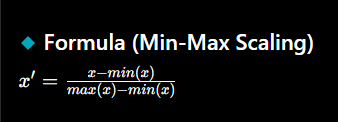

### Sebelum scaling
| Feature | Value |
| ------- | ----- |
| Tempo   | 8     |
| Genre   | 1     |

### sesudah scaling
| Feature | Value |
| ------- | ----- |
| Tempo   | 0.8   |
| Genre   | 1.0   |


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_encoded.copy()

#jangan scale kolom user
df_scaled.iloc[:,1:] = scaler.fit_transform(df_scaled.iloc[:,1:])

C:\Users\ACER\AppData\Local\Temp\ipykernel_4968\1184739003.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.85714286 0.71428571 0.14285714 1.         0.57142857 0.
 0.85714286 0.42857143 0.28571429 1.         0.71428571 0.14285714
 0.57142857 0.85714286 0.         1.         0.42857143 0.28571429
 0.71428571 0.14285714 0.85714286 0.57142857 0.         1.
 0.71428571 0.42857143 0.28571429 0.85714286 0.57142857 0.14285714
 1.         0.71428571 0.42857143 0.28571429 0.         0.85714286
 0.57142857 0.14285714 1.         0.71428571 0.42857143 0.28571429
 0.         0.85714286 0.57142857 0.14285714 1.         0.71428571
 0.42857143 0.28571429]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.iloc[:,1:] = scaler.fit_transform(df_scaled.iloc[:,1:])
C:\Users\ACER\AppData\Local\Temp\ipykernel_4968\1184739003.py:8: FutureWarning: Setting an item of incompatible dtype

In [12]:
similar_users_scaled = find_similar_users(df_scaled, "U1", top_n=5)

for user, dist in similar_users_scaled:
    print(f"{user} -> Distance: {dist}")

U14 -> Distance: 0.39682539682539686
U11 -> Distance: 0.4900793650793651
U32 -> Distance: 2.3968253968253967
U3 -> Distance: 2.4027777777777777
U36 -> Distance: 2.4107142857142856


In [13]:
order1 = ["U14","U11","U32","U36","U4"]

df_ordered = df.set_index("User").loc[order1].reset_index()

print(df_ordered)

  User  Tempo  Energy  Acousticness  Danceability Genre   Mood
0  U14      8       8             3             8  Jazz    Sad
1  U11      7       6             4             7  Jazz    Sad
2  U32      7       7             3             8  Jazz  Happy
3  U36      8       8             2             9  Rock    Sad
4   U4      9       8             2             9  Jazz  Happy


In [14]:
order2 = ["U14","U11","U32","U3","U36"]

df_ordered = df.set_index("User").loc[order2].reset_index()

print(df_ordered)

  User  Tempo  Energy  Acousticness  Danceability Genre   Mood
0  U14      8       8             3             8  Jazz    Sad
1  U11      7       6             4             7  Jazz    Sad
2  U32      7       7             3             8  Jazz  Happy
3   U3      3       4             8             2  Jazz    Sad
4  U36      8       8             2             9  Rock    Sad


## 📌Insight (refined)

Setelah dilakukan normalisasi menggunakan Min-Max Scaling, perubahan ranking terjadi pada posisi ke-4 dan ke-5. Hal ini menunjukkan bahwa sebelumnya fitur numerik seperti tempo dan energy mendominasi perhitungan jarak.

Setelah scaling, fitur kategorikal seperti genre dan mood memiliki kontribusi yang lebih seimbang, sehingga user dengan kesamaan kategori dapat naik peringkat meskipun memiliki perbedaan numerik yang cukup besar.

Namun demikian, hasil ini juga menunjukkan bahwa normalisasi tidak selalu menghasilkan similarity yang lebih “realistis”, sehingga diperlukan pendekatan lanjutan seperti weighted distance untuk menyesuaikan tingkat kepentingan masing-masing fitur.

# Konsep Weighted Distance

- 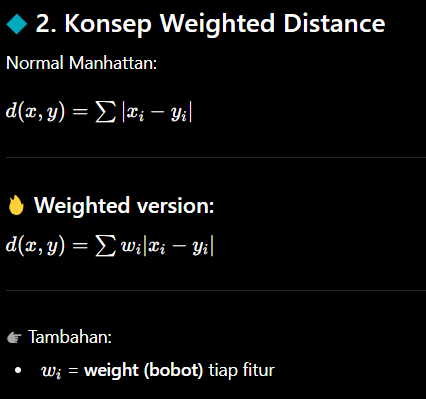

👉 Tambahan: Wi = weight (bobot) tiap fitur

### Intuisi sederhana
#### Bayangkan

| Feature | Weight | Arti           |
| ------- | ------ | -------------- |
| Tempo   | 3      | penting banget |
| Energy  | 2      | cukup penting  |
| Genre   | 1      | biasa saja     |
| Mood    | 1      | biasa saja     |

🔥 Dampaknya:
- Kalau beda di:
- Tempo → penalti besar
- Genre → penalti kecil

👉 Jadi model bilang:
“Lebih baik beda genre daripada beda tempo jauh”

#### Kenapa ini powerful?
Karena kamu bisa:
✅ Encode domain knowledge

Contoh:
- Musik EDM → tempo penting
- Podcast → tempo tidak penting

#### 👉 Weighted distance = “prioritas dalam penilaian”

- | Konsep    | Fungsi          |
| --------- | --------------- |
| Manhattan | hitung jarak    |
| Scaling   | bikin fair      |
| Weighting | kasih prioritas |


### Model ≠ kebenaran

### Model = representasi dari asumsi kita

Contoh nyata:

- Spotify → beda hasil dari YouTube
- Netflix → beda dari IMDb

-👉 Kenapa?
-➡️ Karena mereka pakai assumption berbeda


#### Quotes:

    “Building a recommendation system is not solely about numerical optimization, but also about designing meaningful similarity that reflects human preferences. A good model balances mathematical precision with contextual reasoning, ensuring that recommendations remain both accurate and interpretable.”

# Weighted Manhattan Distance

- Normalnya semua fitur dianggap sama penting, Yang kali ini jadi ide utama adalah "TIAP FITUR MEMILIKI BOBOTNYA TERSENDIRI"
- Logika sederhananya: Tempo = Sangat Penting, Energy = Penting, Genre/Mood = Tambahan saja.
- Dengan Skala 3 (Penting Sekali), 2 (Penting), 1 (Tambahan saja)
## Implementasi

In [15]:
#Buat Weight Vector

weights = []

for col in df_encoded.columns:
    if col == "User":
        continue
    elif "Tempo" in col:
        weights.append(3)
    elif "Energy" in col:
        weights.append(2)
    elif "Acousticness" in col:
        weights.append(1)
    elif "Danceability" in col:
        weights.append(2)
    elif "Genre" in col:
        weights.append(1)
    elif "Mood" in col:
        weights.append(1)

weights = np.array(weights)

### Weighted Manhattan Function

In [16]:
def weighted_manhattan(a, b, weights):
    return np.sum(weights * np.abs(a-b))

### Update Function Similarity

In [17]:
def find_similar_users_weighted(df, target_user_id, weights, top_n=5):

    if "User" not in df.columns:
        df = df.reset_index()

    df_numeric = df.drop(columns=["User"])

    target_row = df[df["User"] == target_user_id]
    target_vector = target_row.drop(columns=["User"]).values[0]

    distances = []

    for i, row in df.iterrows():
        user_id = row["User"]

        if user_id == target_user_id:
            continue

        row_vector = row.drop(labels=["User"]).values

        dist = weighted_manhattan(target_vector, row_vector, weights)
        distances.append((user_id, dist))

    distances.sort(key=lambda x: x[1])

    return distances[:top_n]

### Testing

In [18]:
similar_users_weighted = find_similar_users_weighted(
    df_encoded, "U1", weights, top_n=5
)

for user, dist in similar_users_weighted:
    print(user, "->", dist)

U14 -> 6
U21 -> 7
U36 -> 7
U11 -> 8
U32 -> 9


In [19]:
order3 = ["U14","U21","U36","U11","U32"]

df_ordered = df.set_index("User").loc[order3].reset_index()

print(df_ordered)

  User  Tempo  Energy  Acousticness  Danceability Genre   Mood
0  U14      8       8             3             8  Jazz    Sad
1  U21      8       7             2             9   Pop  Chill
2  U36      8       8             2             9  Rock    Sad
3  U11      7       6             4             7  Jazz    Sad
4  U32      7       7             3             8  Jazz  Happy


In [20]:
print(len(weights))
print(len(df_encoded.columns) - 1)

10
10


## Comparative Analysis: Scaling vs Weighted Manhattan Distance

By comparing Manhattan Distance, Scaling, and Weighted Manhattan Distance, several changes in similarity trends can be observed.

- User U14 consistently remains in the top position across different approaches.
- After applying Weighted Manhattan Distance, U21 emerges as a new second-ranked similar user.
- U36 shows an increasing similarity trend, moving from rank 5 and 4 into rank 3.
- Meanwhile, U11 and U32 experience slight decreases in ranking positions.

### Key Observations

1. Compared to the scaling-only approach, the weighted model reduces extreme tempo gaps between users. Previously, users with significantly different tempo preferences (e.g., 8 vs 3) could still appear highly similar. After feature weighting, tempo values among top-ranked users become more consistent, generally ranging between 7 and 8.

2. Genre diversity becomes more balanced in the weighted approach. The top-ranked users now represent multiple genres including Jazz, Pop, and Rock.

3. Feature weighting produces a more balanced similarity calculation by emphasizing more important musical characteristics.

> “By introducing feature weighting, the similarity calculation better reflects domain priorities, where core musical attributes such as tempo and energy contribute more significantly than categorical preferences.”

## Reflection and Insights

This project highlights that recommendation systems are not only about algorithms, but also about how human preferences are represented mathematically.

Several important observations were discovered during the analysis:

- Distance metrics are highly sensitive to feature scaling.
- Different features may contribute differently to user similarity.
- Weighted distance can produce more realistic recommendation behavior.
- Data representation strongly influences recommendation results.

The project also demonstrates that model outputs should not automatically be interpreted as objective truth, since feature selection and weighting decisions directly affect similarity calculations.

# Final Conclusion

This project demonstrates how Manhattan Distance can be applied to measure user similarity in a simple music recommendation scenario.

Through the experiments, several important insights were observed:

- Numerical features can dominate similarity calculations.
- Scaling helps create fairer feature contributions.
- Weighted distance allows domain knowledge to be incorporated into the model.
- Recommendation systems are highly dependent on feature representation and modeling assumptions.

Overall, this notebook serves as an educational exploration of similarity analysis, feature engineering, and foundational recommendation system concepts.

## Future Improvements

Possible future developments for this project include:

- Implementing Euclidean Distance and Cosine Similarity
- Building a K-Nearest Neighbors (KNN) recommendation system
- Adding contextual features such as listening activities (gym, studying, relaxing)
- Using real-world music datasets
- Visualizing similarity networks and clustering users
- Developing a context-aware recommendation system